# Part-B: Mount your Google Drive folder

Note that when you start Google Colab, you start to work in a new environment where your previously saved data is gone. Hence, it is super useful to load data directly from an online drive such as Google Drive, where you store your data ahead of time or permanently. You might also hope to store intermediate results to Google Drive too. Below explains how to make this happen. Refer to Part-B of the "instruction-001.pdf" file.

In [1]:
'''
Let's import useful and "standard" packages.
Not all packages will be used in the course. But it is good to know these common packages.
'''

import numpy as np # numpy is a powerful package for numeric calculation, we rename it as "np"
import sys, os # these are system related packages
import pickle # pickle is a cute package to save and load your custom data
import scipy, sklearn, skimage, math # these are useful packages for scientific computing, machine learning, image processing, and math calculation
import matplotlib.pyplot as plt # this is a powerful package for visualization, e.g., curves, bar charts, histograms, and various visualizations.
import cv2 # this is a powerful package for computer vision

In [2]:
'''
Let's import the PyTorch package, which is the most widely used toolbox used for deep learning.
'''
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.nn.functional as F
from torch.autograd import Variable
import torchvision
from torchvision import datasets, models, transforms

In [3]:
# check the versions of your system and pytorch
print(sys.version)
print(torch.__version__)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
2.11.0+cu128


In [4]:
# Check the specifications of your machine/what resources you have been allocated through Colab.
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Fri Jun 26 05:43:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
# cpu or cuda? This code snippet will tell you.
device ='cpu'
if torch.cuda.is_available():
    device='cuda:0'
print(device)


cuda:0


In [6]:
from google.colab import drive # you can allow Google Colab to access your google drive, where you can save your data
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [20]:
'''
let's read an image
'''

foldername = '/content/gdrive/MyDrive/OIST-mini-course'
im = skimage.io.imread(os.path.join(foldername, 'test-image.jpg'))

In [21]:
'''
let's output the format and statistics of this image
'''
print(type(im))
print(im.shape)
print(type(im[0,0]), im.max(), im.min())

<class 'numpy.ndarray'>
(535, 684)
<class 'numpy.uint8'> 255 0


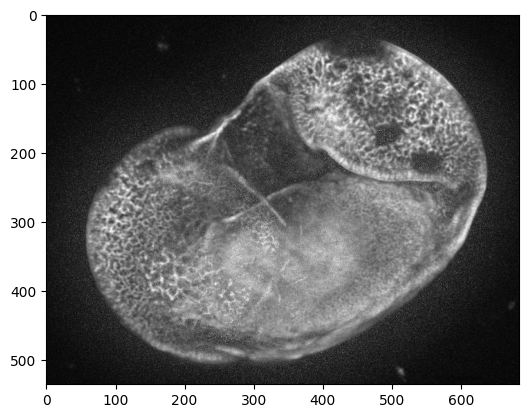

In [22]:
# let's visualize this image in gray scale
plt.imshow(im, cmap='gray')


(365940,)


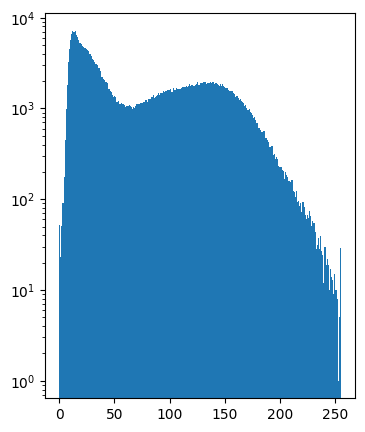

In [23]:
# show histogram of pixel value distributions

# resize the image into a vector, which will be used for histogram generation
x = im.reshape(-1,)
print(x.shape) # print the size of this vector

fig, axes = plt.subplots(1, 1, figsize=(4, 5))
plt.hist(x, 256); # show the histogram of pixel value distribution
plt.yscale('log')

## image processing using histogram equalization

In [27]:
from skimage import io, data, exposure # import useful packages for image processing

In [28]:
img_rescale = exposure.equalize_hist(im.astype(np.double))
img_rescale.max(), img_rescale.min()

(np.float64(1.0), np.float64(0.000142099797781057))

Text(0, 0.5, 'Cumulative Probability')

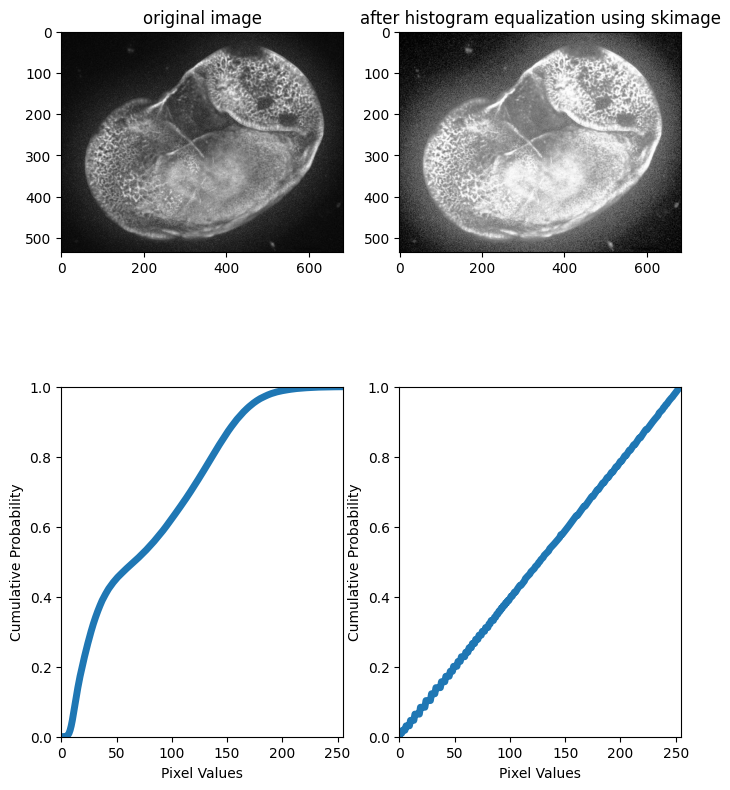

In [29]:
img_rescale = exposure.equalize_hist(im.astype(np.double))
img_rescale *= 255
img_rescale = np.clip(img_rescale, a_min=0, a_max=255)
img_rescale = img_rescale.astype(np.uint8)


cdfImageInput, binsImageInput = exposure.cumulative_distribution(im)
cdfImageInput_rescale, binsImageInput_rescale = exposure.cumulative_distribution(img_rescale)

fig, axes = plt.subplots(2, 2, figsize=(8, 10))

plt.subplot(2, 2, 1)
plt.imshow(im, cmap='gray')
plt.title('original image')

plt.subplot(2, 2, 2)
plt.imshow(img_rescale, cmap='gray')
plt.title('after histogram equalization using skimage')




plt.subplot(2, 2, 3)
plt.plot(binsImageInput, cdfImageInput, linewidth=5)
plt.xlim(0,255)
plt.ylim(0,1)
plt.xlabel('Pixel Values')
plt.ylabel('Cumulative Probability')


plt.subplot(2, 2, 4)
plt.plot(binsImageInput_rescale, cdfImageInput_rescale, linewidth=5)
plt.xlim(0,255)
plt.ylim(0,1)
plt.xlabel('Pixel Values')
plt.ylabel('Cumulative Probability')

## image processing by sharpening

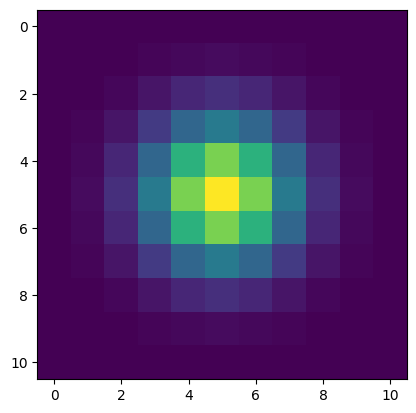

In [33]:
# define a function to create Gaussian filter
def create_gaussian_kernel(filter_size, sigma):
    """Creates a 2D Gaussian kernel."""
    kernel = np.zeros((filter_size, filter_size), dtype=np.float32)
    center = filter_size // 2
    x, y = np.meshgrid(np.arange(-center, center + 1), np.arange(-center, center + 1))
    kernel = (1 / (2 * np.pi * sigma**2)) * np.exp(-(x**2 + y**2) / (2 * filter_sigma**2))
    return kernel / np.sum(kernel) # Normalize the kernel


filter_size = 11
filter_sigma = 1.5
gaussian_filter = create_gaussian_kernel(filter_size, filter_sigma)

plt.imshow(gaussian_filter)

In [34]:
from scipy import signal # let's use a third-part toolbox called scipy to convolve an image with a defined filter
img_gauss_blurred = signal.convolve2d(im, gaussian_filter, 'same')


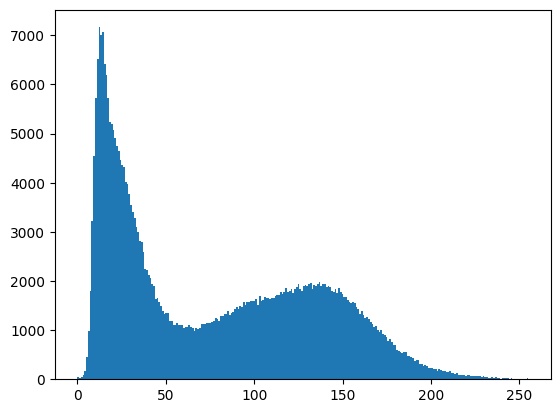

In [35]:
tmp = im.reshape(-1)
plt.hist(tmp, 256);

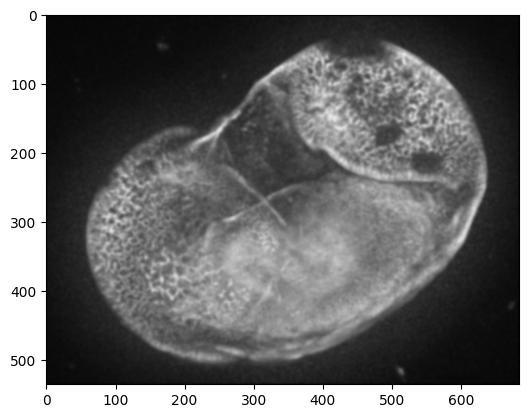

In [37]:
filter_size = 11
filter_sigma = 1.5
gaussian_filter = create_gaussian_kernel(filter_size, filter_sigma)
img_gauss_blurred = signal.convolve2d(im, gaussian_filter, 'same')
plt.imshow(img_gauss_blurred, cmap='gray', vmin=0, vmax=255)

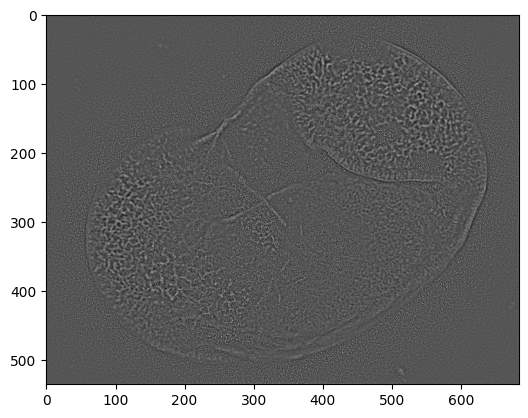

In [39]:
unsharp_mask = im - img_gauss_blurred
plt.imshow(unsharp_mask, 'gray')

Text(0.5, 1.0, 'magnifier=3.0')

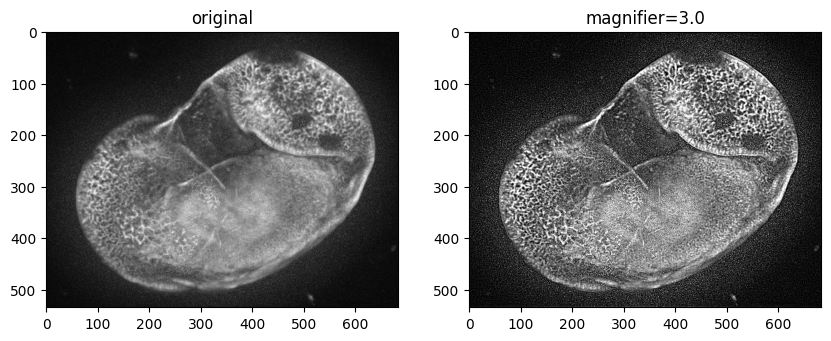

In [49]:
magnifier = 3.0
img_new = im + magnifier*unsharp_mask

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(im, cmap='gray', vmin=0, vmax=255)
plt.title('original')

plt.subplot(1, 2, 2)
plt.imshow(img_new, cmap='gray', vmin=0, vmax=255)
plt.title('magnifier=%.1f' % magnifier)

In [50]:
# understand the max and min values and the data type
img_new.max(), img_new.min()

(np.float64(528.6353749683612), np.float64(-139.15952138965258))

In [51]:
# clip values
img_new[img_new<0] = 0
img_new[img_new>255] = 255
img_new = img_new.astype(np.uint8)

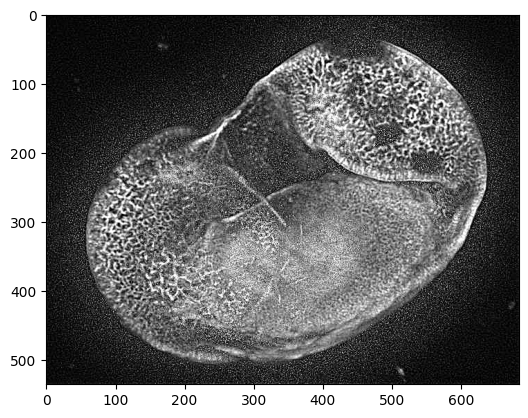

In [52]:
plt.imshow(img_new, 'gray')

In [55]:
# save the image to your Google Drive, i.e., using the following path
print(foldername)

/content/gdrive/MyDrive/OIST-mini-course


In [56]:
io.imsave(os.path.join(foldername, 'test-image-sharpened.jpg'), img_new)
